In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ROOT
mpl.rc('text', usetex = True)

In [4]:
# Only limited to spin-1 so can have it be a bit hardcodey
# Changing from root branch name to wave format
# i.e. a_T_1_0 = P^+_{T0}
def ToWave(x):
   tmp = x.split('_')
   refl = "+"
   pol = tmp[1]
   wave = "S"
   m = "0"

   if (tmp[0] == 'b'):
       refl = "-"
   if (tmp[2] == '1'):
       wave = "P"
   if (tmp[3] == '1'):
       m = "1"
   elif (tmp[3] == 'm1'):
       m = "-1"

   return wave+"$^"+refl+"_{\\mathrm{" +pol + "}" + m + "}$"

In [5]:
def circular_mean(phi):
    return np.angle(np.mean(np.exp(1j * phi)))

def circular_std(phi):
    R = np.abs(np.mean(np.exp(1j * phi)))
    return np.sqrt(-2 * np.log(R))

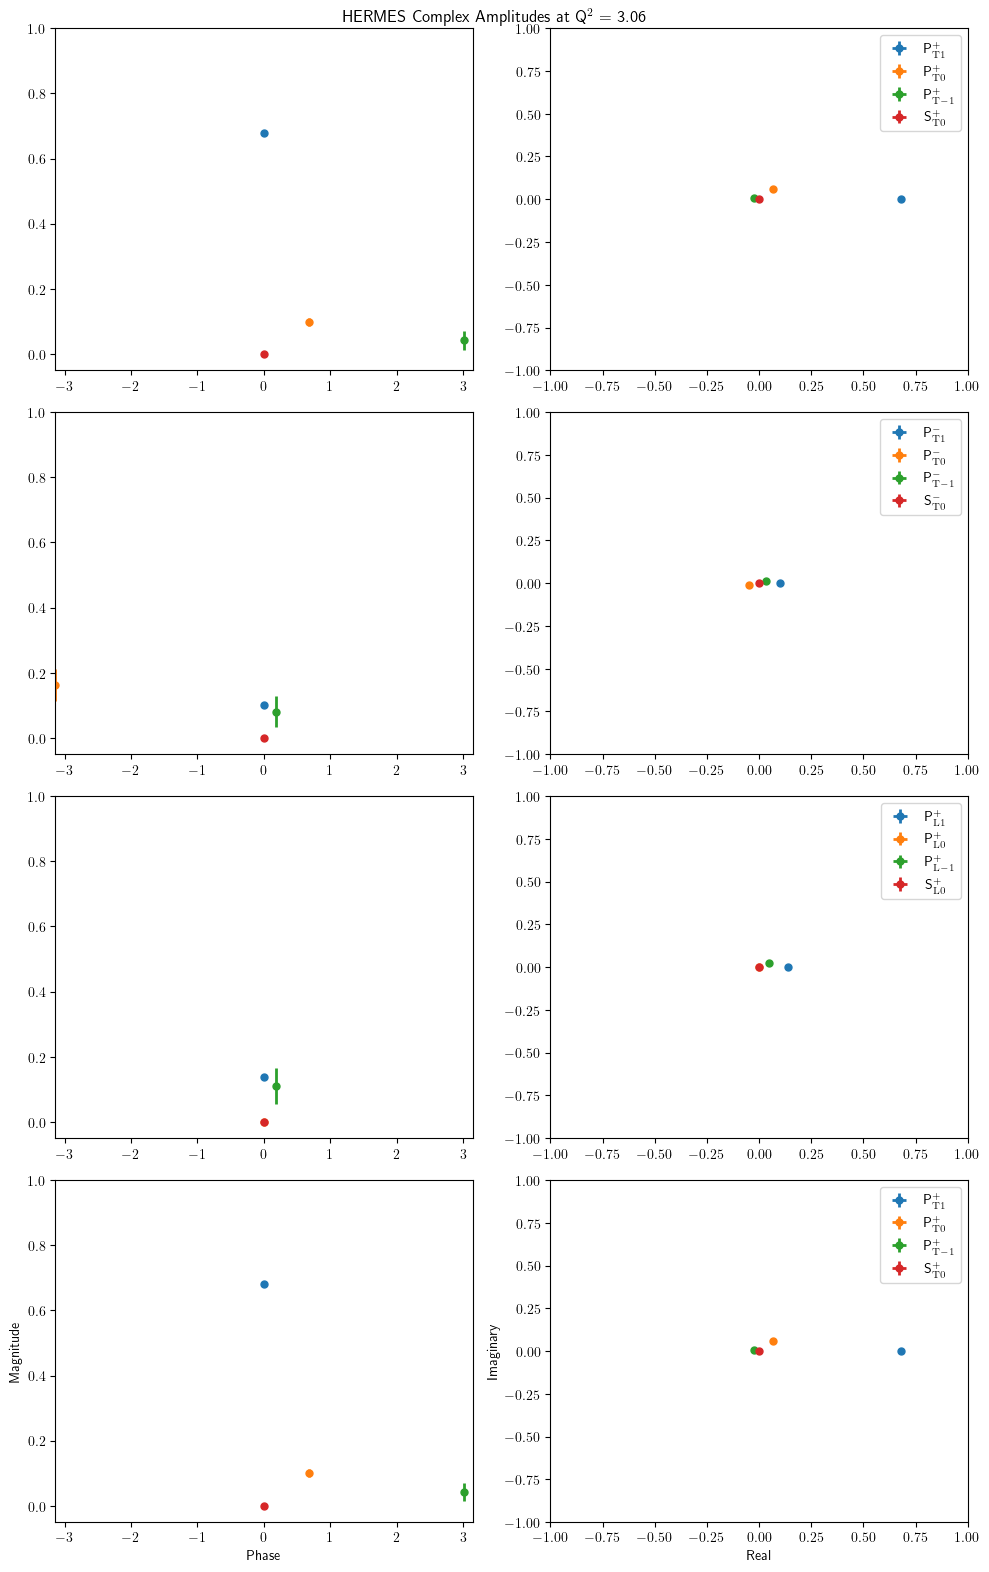

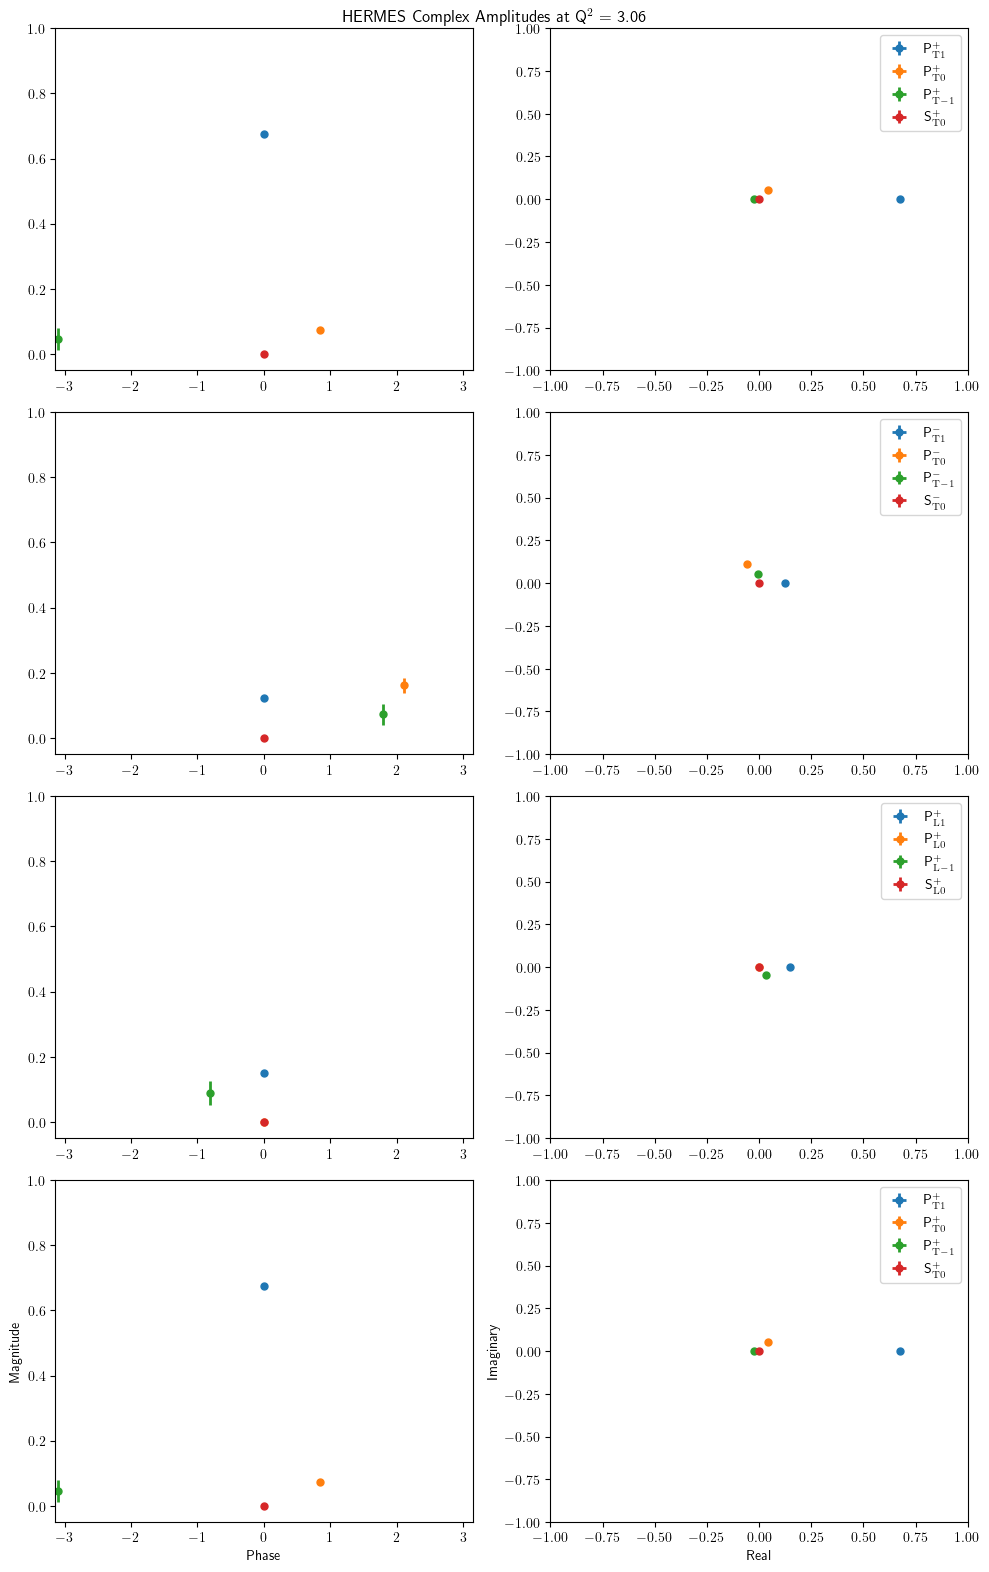

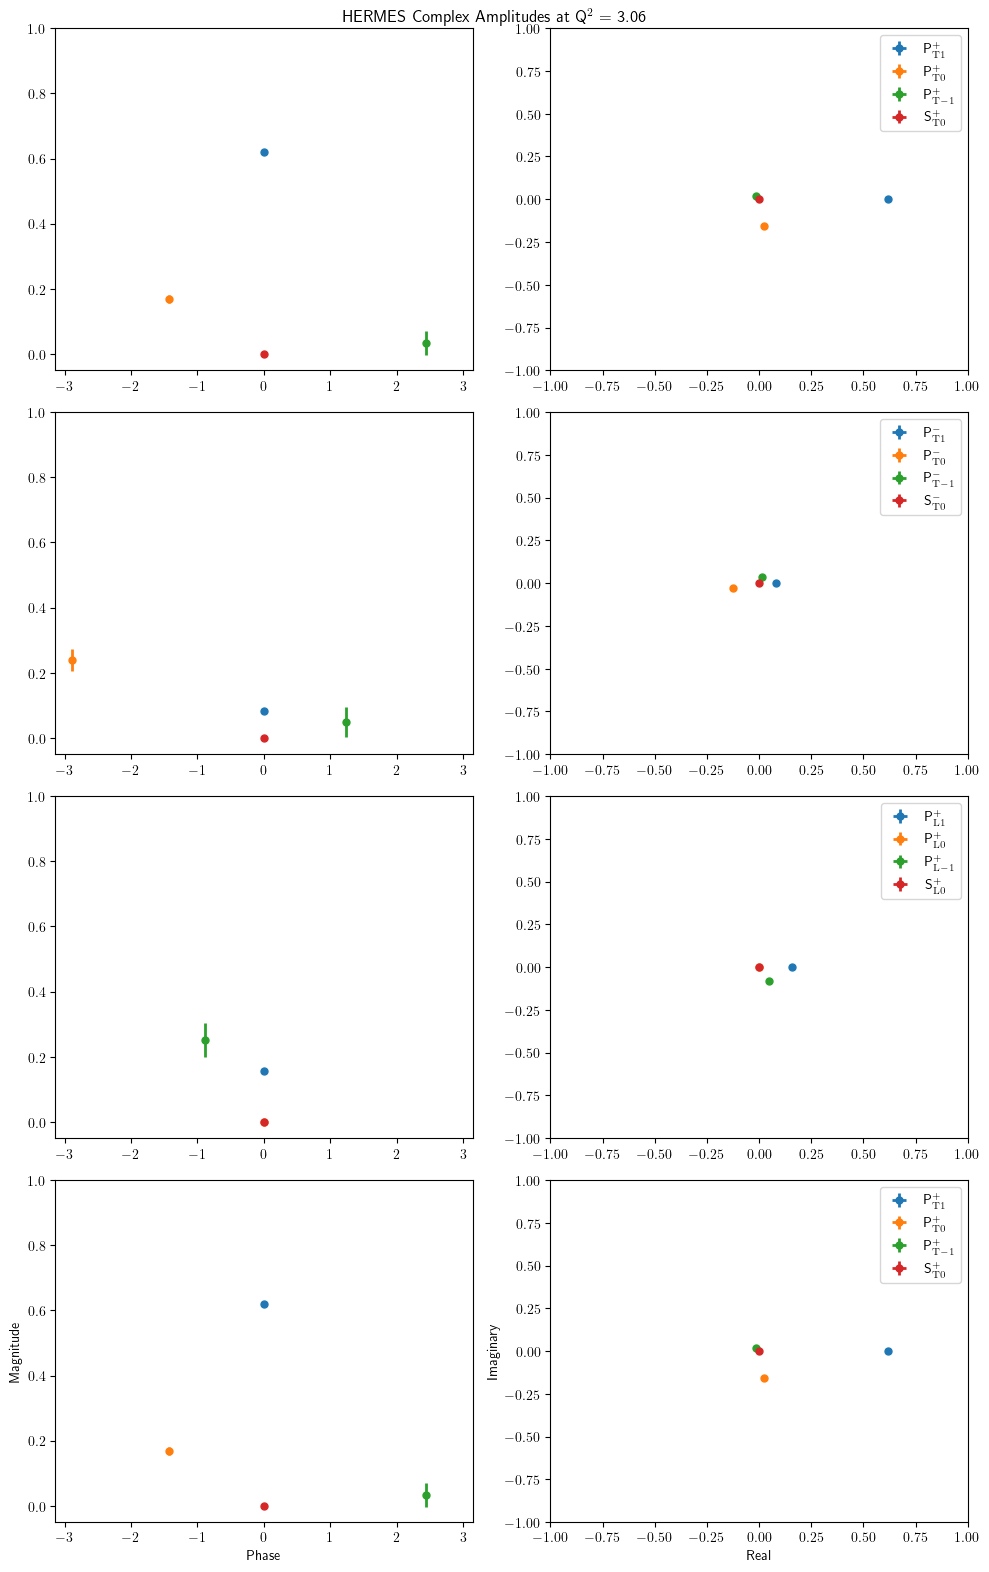

In [7]:
# Initialise arrays for each wave
aT = np.empty(4)
bT = np.empty(4)
aL = np.empty(4)
bL = np.empty(4)

# DataFrame column names
cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
        "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
        "a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_0_0",
        "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_0_0",
        "aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0"]

Q2 = np.array([0.82, 1.19, 1.66, 3.06])

# For HERMEs data they are saved this way (4 Q2 bins)
for i in [1,2,3]:
    df = ROOT.RDataFrame("toyFitResults", "~/Desktop/PhD/Electroproduction/brufit/tutorials/ElectroAmps/TwoSpin0AmpsFromMoments/resultsGivenMoments_chi2_errors"+str(i)+".root")

    arrays_mag = df.AsNumpy(columns=cols_mag)
    arrays_phase = df.AsNumpy(columns=cols_phase)

    # All arrays have the same length
    N = np.shape(arrays_mag[cols_mag[0]])[0]

    fig = plt.figure(figsize=(10,16))
    axs = fig.subplots(4,2)
    for j in range(4):
        #The main plotting
        for k in range(4):
            y = arrays_mag[cols_mag[k + 4*j]]
            x = arrays_phase[cols_phase[k + 4*j]]

            re = y*np.cos(x)
            im = y*np.sin(x)

            mean_y = np.mean(y)
            err_y = np.std(y) / np.sqrt(N)

            mean_x = circular_mean(x)
            err_x= circular_std(x) / np.sqrt(N)

            mean_re = np.mean(re)
            err_re= np.std(re) / np.sqrt(N)

            mean_im = np.mean(im)
            err_im = np.std(im) / np.sqrt(N)

            axs[j,0].errorbar(mean_x,mean_y,err_x,err_y, fmt='.', markersize=10, elinewidth=2)
            axs[j,0].axis(xmin=-np.pi, xmax = np.pi, ymin = -0.05, ymax = 1)

            axs[j,1].errorbar(mean_re,mean_im,err_re,err_im, fmt='.', markersize=10, elinewidth=2, label=ToWave(cols_mag[k + 4*j]))
            axs[j,1].axis(xmin=-1, xmax = 1, ymin = -1, ymax = 1)

            axs[j,0].set_ylabel("Magnitude")
            axs[j,1].set_ylabel("Imaginary")
            if (j==3):
                axs[j,0].set_xlabel("Phase")
                axs[j,1].set_xlabel("Real")


            axs[j,1].legend()
        # Maybe have an overall title giving more information?
        fig.suptitle("HERMES Complex Amplitudes at Q$^2$ = {0}".format(Q2[j]), size=18)
        fig.tight_layout()
        fig.savefig("results_err"+str(i)+".png", format= 'png')
